In [25]:
# fetch data
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid", palette="Set2")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")

DATA_DIR = Path('.\\heart+disease')
FILE_NAMES = [
    "processed.cleveland.data",
    "processed.hungarian.data",
    "processed.switzerland.data",
    "processed.va.data",
]
FEATURE_NAMES = [
    "age", "sex", "cp", "trestbps", "chol", "fbs", "restecg",
    "thalach", "exang", "oldpeak", "slope", "ca", "thal", "target"
]

frames = []
for file_name in FILE_NAMES:
    file_path = DATA_DIR / file_name
    if not file_path.exists():
        raise FileNotFoundError(f"File tidak ditemukan: {file_path}")
    frame = pd.read_csv(file_path, header=None, names=FEATURE_NAMES, na_values="?")
    frame["source_file"] = file_name
    frames.append(frame)

df = pd.concat(frames, ignore_index=True)
df[FEATURE_NAMES] = df[FEATURE_NAMES].apply(pd.to_numeric, errors="coerce")
df["target_binary"] = (df["target"] > 0).astype("Int64")

print(f"Dataset berhasil dimuat: {df.shape[0]:,} observasi, {len(FEATURE_NAMES):,} fitur asli")
display(df.head())

Dataset berhasil dimuat: 920 observasi, 14 fitur asli


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,source_file,target_binary
0,63.000,1.000,1.000,145.000,233.000,1.000,2.000,150.000,0.000,2.300,3.000,0.000,6.000,0,processed.cleveland.data,0
1,67.000,1.000,4.000,160.000,286.000,0.000,2.000,108.000,1.000,1.500,2.000,3.000,3.000,2,processed.cleveland.data,1
2,67.000,1.000,4.000,120.000,229.000,0.000,2.000,129.000,1.000,2.600,2.000,2.000,7.000,1,processed.cleveland.data,1
3,37.000,1.000,3.000,130.000,250.000,0.000,0.000,187.000,0.000,3.500,3.000,0.000,3.000,0,processed.cleveland.data,0
4,41.000,0.000,2.000,130.000,204.000,0.000,2.000,172.000,0.000,1.400,1.000,0.000,3.000,0,processed.cleveland.data,0


# Takeout target column

In [26]:
df.drop(columns=["target"], inplace=True)
df.rename(columns={"target_binary": "target"}, inplace=True)
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,source_file,target
0,63.000,1.000,1.000,145.000,233.000,1.000,2.000,150.000,0.000,2.300,3.000,0.000,6.000,processed.cleveland.data,0
1,67.000,1.000,4.000,160.000,286.000,0.000,2.000,108.000,1.000,1.500,2.000,3.000,3.000,processed.cleveland.data,1
2,67.000,1.000,4.000,120.000,229.000,0.000,2.000,129.000,1.000,2.600,2.000,2.000,7.000,processed.cleveland.data,1
3,37.000,1.000,3.000,130.000,250.000,0.000,0.000,187.000,0.000,3.500,3.000,0.000,3.000,processed.cleveland.data,0
4,41.000,0.000,2.000,130.000,204.000,0.000,2.000,172.000,0.000,1.400,1.000,0.000,3.000,processed.cleveland.data,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
915,54.000,0.000,4.000,127.000,333.000,1.000,1.000,154.000,0.000,0.000,NaN,NaN,NaN,processed.va.data,1
916,62.000,1.000,1.000,NaN,139.000,0.000,1.000,NaN,NaN,NaN,NaN,NaN,NaN,processed.va.data,0
917,55.000,1.000,4.000,122.000,223.000,1.000,1.000,100.000,0.000,0.000,NaN,NaN,6.000,processed.va.data,1
918,58.000,1.000,4.000,NaN,385.000,1.000,2.000,NaN,NaN,NaN,NaN,NaN,NaN,processed.va.data,0


# Dataset Understanding dan Exploratory Data Analysis

Notebook ini menganalisis empat subset UCI Heart Disease secara gabungan. `target` asli memiliki nilai 0-4; untuk analisis klasifikasi, `target_binary` berarti 0 = tidak ada penyakit dan 1 = ada penyakit (`target > 0`).

1. JUMLAH OBSERVASI DAN FITUR
Observasi: 920
Fitur asli: 13 | Target: 1 | Kolom metadata: source_file, target

2. TIPE SETIAP FITUR


,feature,dtype,n_unique
0,age,float64,50
1,sex,float64,2
2,cp,float64,4
3,trestbps,float64,61
4,chol,float64,217
5,fbs,float64,2
6,restecg,float64,3
7,thalach,float64,119
8,exang,float64,2
9,oldpeak,float64,53


3. DISTRIBUSI TARGET


,count,percentage
target,,
0,411,44.674
1,509,55.326


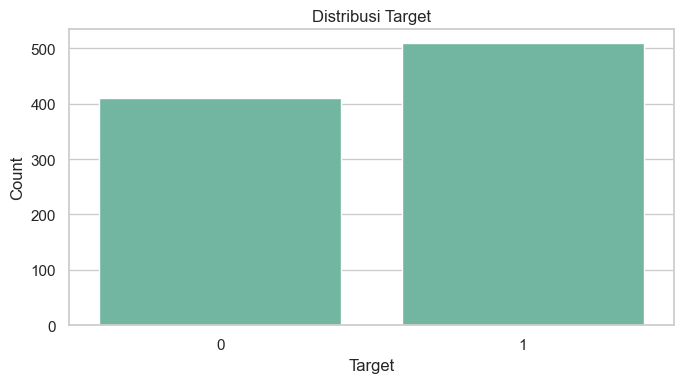

4. MISSING VALUES


,missing_count,missing_percentage
ca,611,66.413
thal,486,52.826
slope,309,33.587
fbs,90,9.783
oldpeak,62,6.739
trestbps,59,6.413
thalach,55,5.978
exang,55,5.978
chol,30,3.261
restecg,2,0.217


5. DUPLICATE RECORDS
Duplikat penuh (tanpa source_file): 2
Duplikat fitur dengan target berbeda: 4 baris
Duplikat identik antar semua kolom: 2


In [32]:
# 1-5. Ukuran data, tipe fitur, target, missing values, dan duplikasi
print("1. JUMLAH OBSERVASI DAN FITUR")
print(f"Observasi: {len(df):,}")
print(f"Fitur asli: {len(FEATURE_NAMES) - 1:,} | Target: 1 | Kolom metadata: source_file, target")

print("\n2. TIPE SETIAP FITUR")
type_table = pd.DataFrame({
    "feature": df[FEATURE_NAMES].columns,
    "dtype": df[FEATURE_NAMES].dtypes.astype(str).values,
    "n_unique": df[FEATURE_NAMES].nunique(dropna=True).values,
})
display(type_table)

print("3. DISTRIBUSI TARGET")

target_distribution = pd.DataFrame({
    "count": df["target"].value_counts(dropna=False).sort_index(),
    "percentage": df["target"].value_counts(normalize=True, dropna=False).sort_index().mul(100),
})
display(target_distribution)

plt.figure(figsize=(7, 4))
sns.countplot(
    data=df.assign(target_label=df["target"].astype("string").fillna("Missing")),
    x="target_label",
    order=df["target"].astype("string").fillna("Missing").value_counts().sort_index().index
)
plt.title("Distribusi Target")
plt.xlabel("Target")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

print("4. MISSING VALUES")
missing_table = pd.DataFrame({
    "missing_count": df[FEATURE_NAMES].isna().sum(),
    "missing_percentage": df[FEATURE_NAMES].isna().mean().mul(100),
}).sort_values("missing_count", ascending=False)
display(missing_table)

print("5. DUPLICATE RECORDS")
print(f"Duplikat penuh (tanpa source_file): {df[FEATURE_NAMES].duplicated().sum():,}")
print(f"Duplikat fitur dengan target berbeda: {df.duplicated(FEATURE_NAMES[:-1], keep=False).sum():,} baris")
print(f"Duplikat identik antar semua kolom: {df.duplicated().sum():,}")

6. DISTRIBUSI NUMERICAL FEATURES


,count,mean,std,min,25%,50%,75%,max
age,920.000,53.511,9.425,28.000,47.000,54.000,60.000,77.000
trestbps,861.000,132.132,19.066,0.000,120.000,130.000,140.000,200.000
chol,890.000,199.130,110.781,0.000,175.000,223.000,268.000,603.000
thalach,865.000,137.546,25.926,60.000,120.000,140.000,157.000,202.000
oldpeak,858.000,0.879,1.091,-2.600,0.000,0.500,1.500,6.200


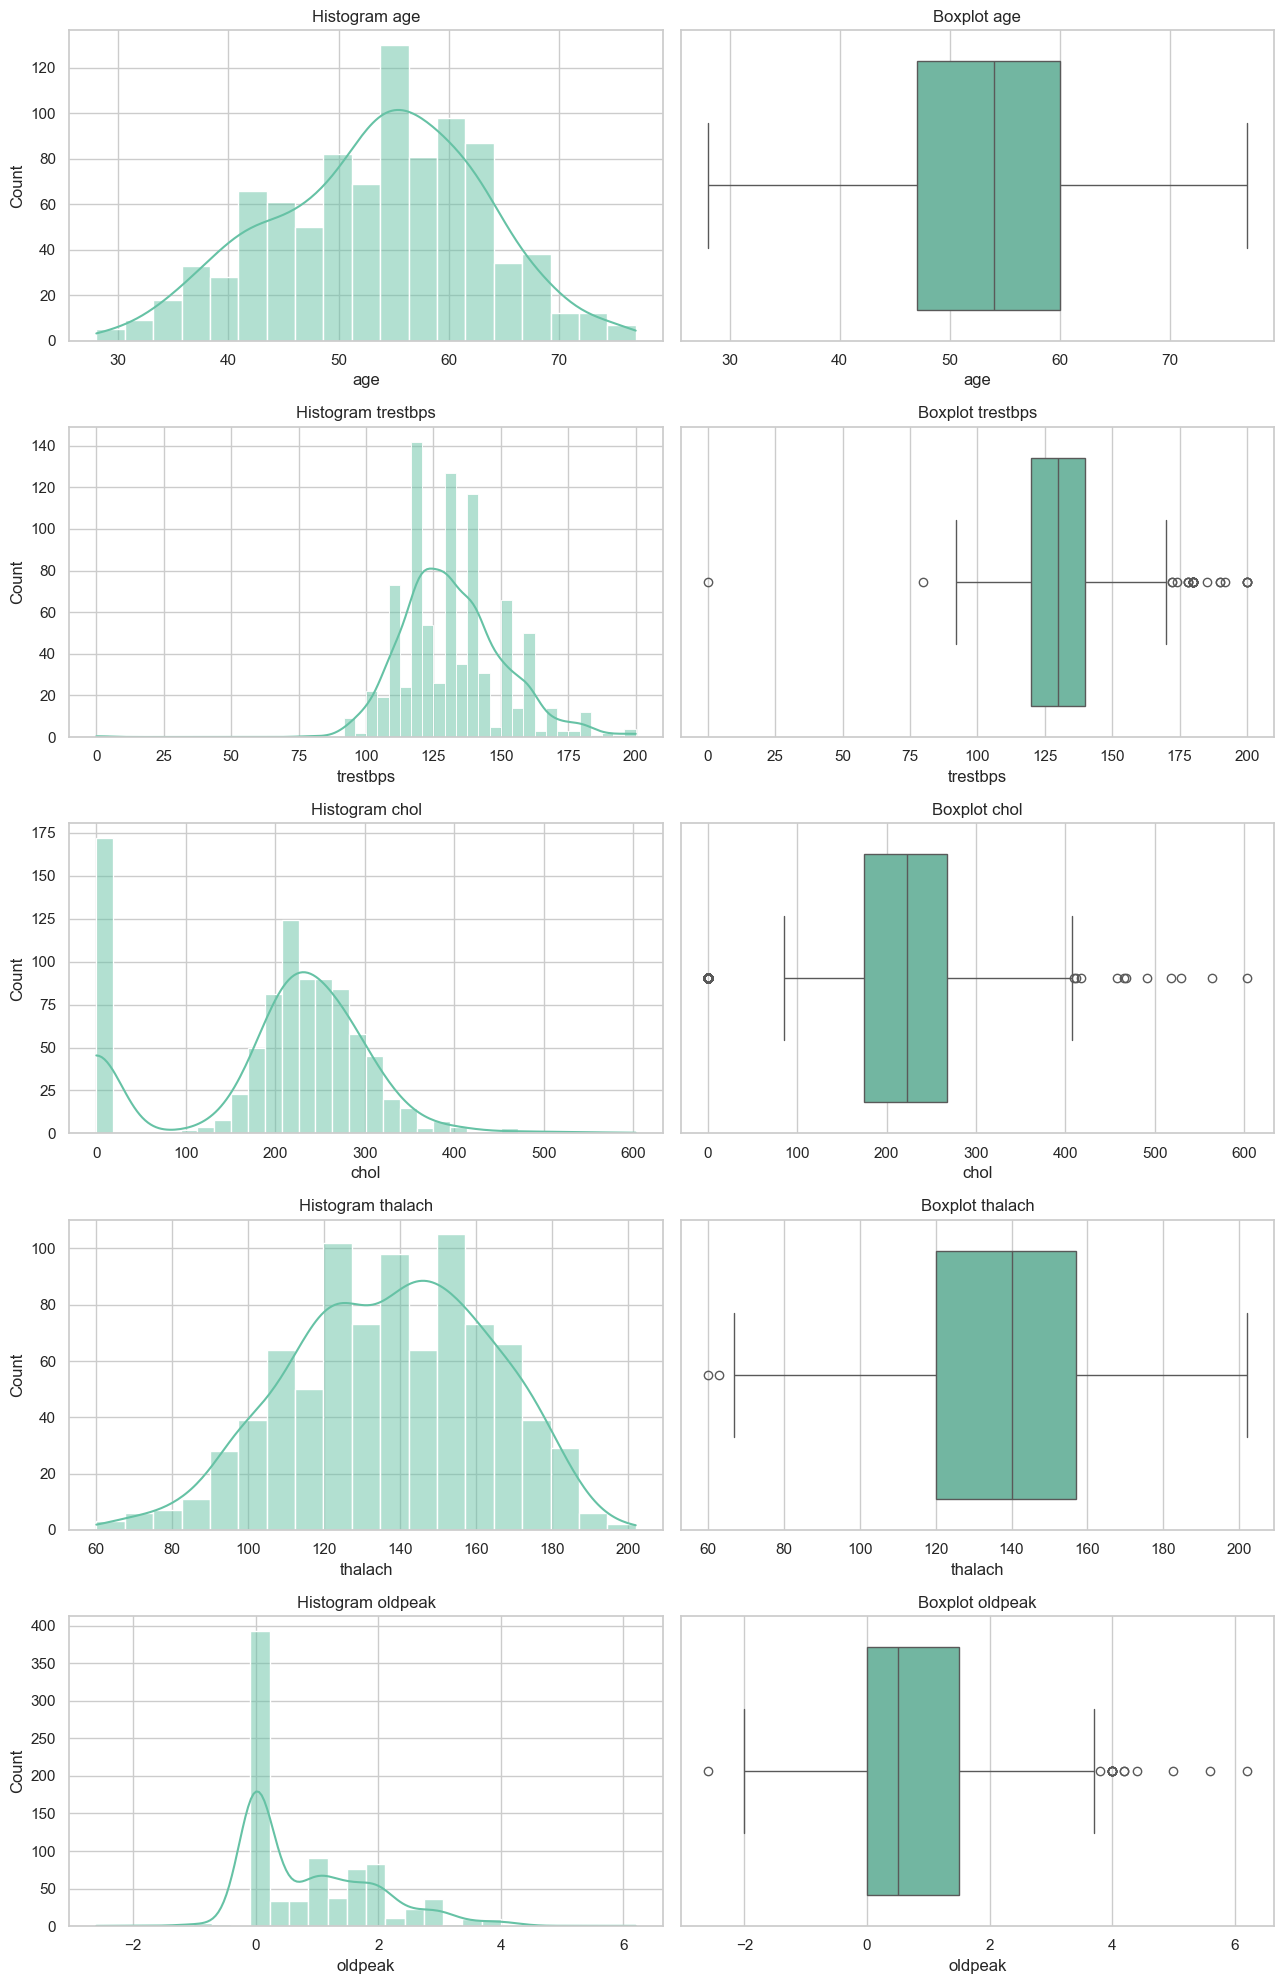

7. DISTRIBUSI CATEGORICAL FEATURES

sex


,count,percentage
sex,,
1.0,726,78.913
0.0,194,21.087


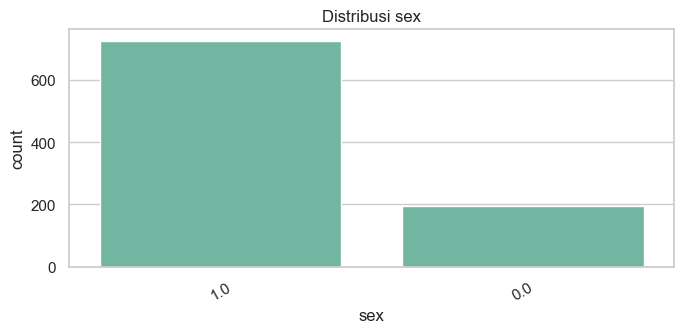


cp


,count,percentage
cp,,
4.0,496,53.913
3.0,204,22.174
2.0,174,18.913
1.0,46,5.000


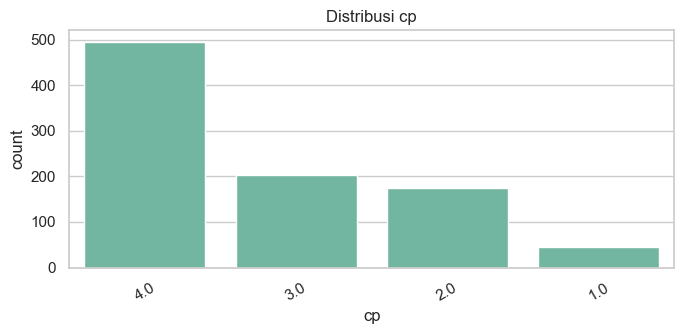


fbs


,count,percentage
fbs,,
0.0,692,75.217
1.0,138,15.000
Missing,90,9.783


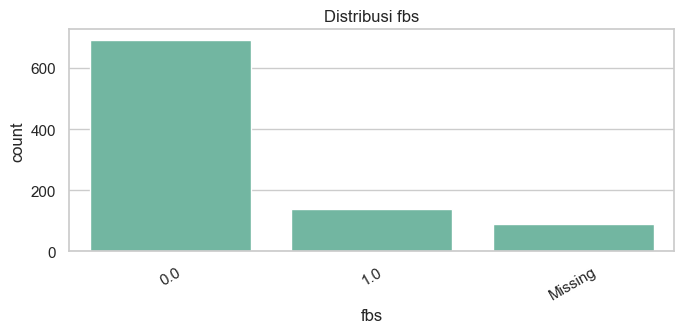


restecg


,count,percentage
restecg,,
0.0,551,59.891
2.0,188,20.435
1.0,179,19.457
Missing,2,0.217


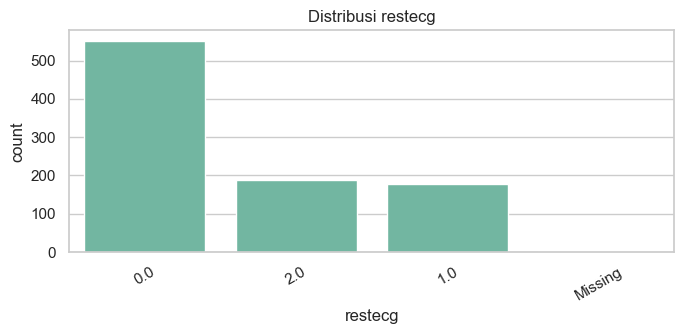


exang


,count,percentage
exang,,
0.0,528,57.391
1.0,337,36.630
Missing,55,5.978


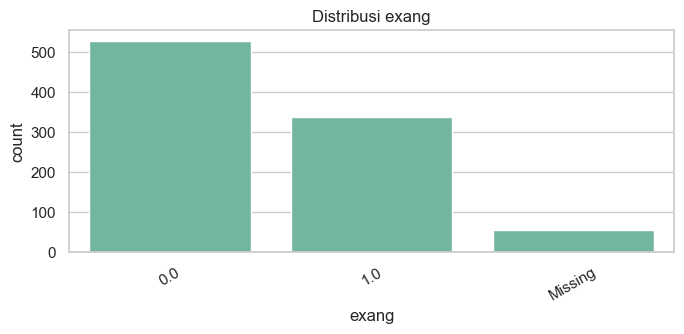


slope


,count,percentage
slope,,
2.0,345,37.500
Missing,309,33.587
1.0,203,22.065
3.0,63,6.848


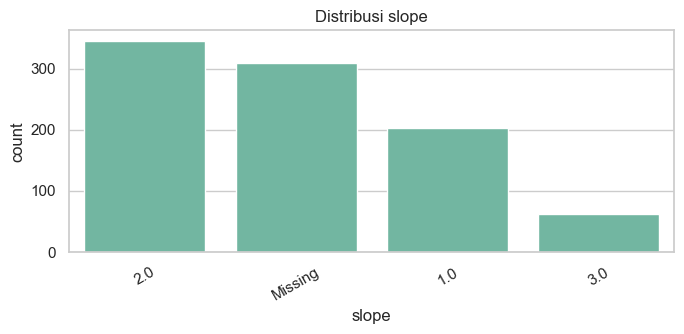


ca


,count,percentage
ca,,
Missing,611,66.413
0.0,181,19.674
1.0,67,7.283
2.0,41,4.457
3.0,20,2.174


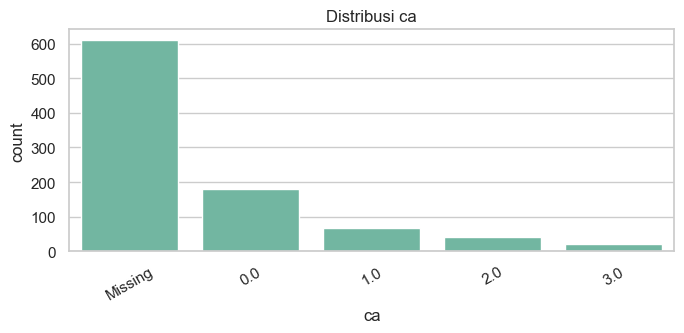


thal


,count,percentage
thal,,
Missing,486,52.826
3.0,196,21.304
7.0,192,20.870
6.0,46,5.000


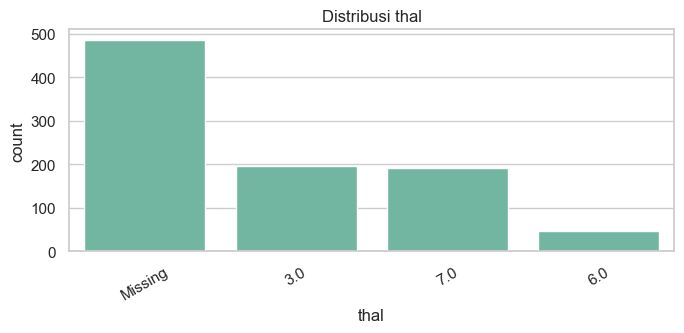

In [34]:
# 6-7. Distribusi fitur numerik dan kategorikal
numeric_features = ["age", "trestbps", "chol", "thalach", "oldpeak"]
categorical_features = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"]

print("6. DISTRIBUSI NUMERICAL FEATURES")
display(df[numeric_features].describe().T)
fig, axes = plt.subplots(len(numeric_features), 2, figsize=(13, 4 * len(numeric_features)))
for row, feature in enumerate(numeric_features):
    sns.histplot(data=df, x=feature, kde=True, ax=axes[row, 0])
    axes[row, 0].set_title(f"Histogram {feature}")
    sns.boxplot(data=df, x=feature, ax=axes[row, 1])
    axes[row, 1].set_title(f"Boxplot {feature}")
plt.tight_layout()
plt.show()

print("7. DISTRIBUSI CATEGORICAL FEATURES")
for feature in categorical_features:
    # ubah NaN jadi string "Missing" supaya tidak bentrok dengan matplotlib
    plot_series = df[feature].fillna("Missing").astype(str)

    distribution = plot_series.value_counts(dropna=False).rename_axis(feature).to_frame("count")
    distribution["percentage"] = distribution["count"].div(len(df)).mul(100)
    print(f"\n{feature}")
    display(distribution)

    plt.figure(figsize=(7, 3.5))
    sns.countplot(x=plot_series, order=plot_series.value_counts(dropna=False).index)
    plt.title(f"Distribusi {feature}")
    plt.xlabel(feature)
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

8. ANOMALOUS VALUES (ATURAN DOMAIN)


,feature,allowed_range,anomaly_count,anomaly_percentage
4,chol,"[50, 700]",172,18.696
3,trestbps,"[50, 250]",1,0.109
0,age,"[0, 120]",0,0.000
1,sex,"[0, 1]",0,0.000
2,cp,"[1, 4]",0,0.000
5,fbs,"[0, 1]",0,0.000
6,restecg,"[0, 2]",0,0.000
7,thalach,"[50, 250]",0,0.000
8,exang,"[0, 1]",0,0.000
9,oldpeak,"[-5, 10]",0,0.000


Catatan: batas domain adalah screening awal; nilai yang lolos tetap perlu ditinjau secara klinis.
9. OUTLIER ANALYSIS (IQR)


,feature,q1,q3,lower_bound,upper_bound,outlier_count,outlier_percentage
2,chol,175.000,268.000,35.500,407.500,183,19.891
1,trestbps,120.000,140.000,90.000,170.000,28,3.043
4,oldpeak,0.000,1.500,-2.250,3.750,16,1.739
3,thalach,120.000,157.000,64.500,212.500,2,0.217
0,age,47.000,60.000,27.500,79.500,0,0.000


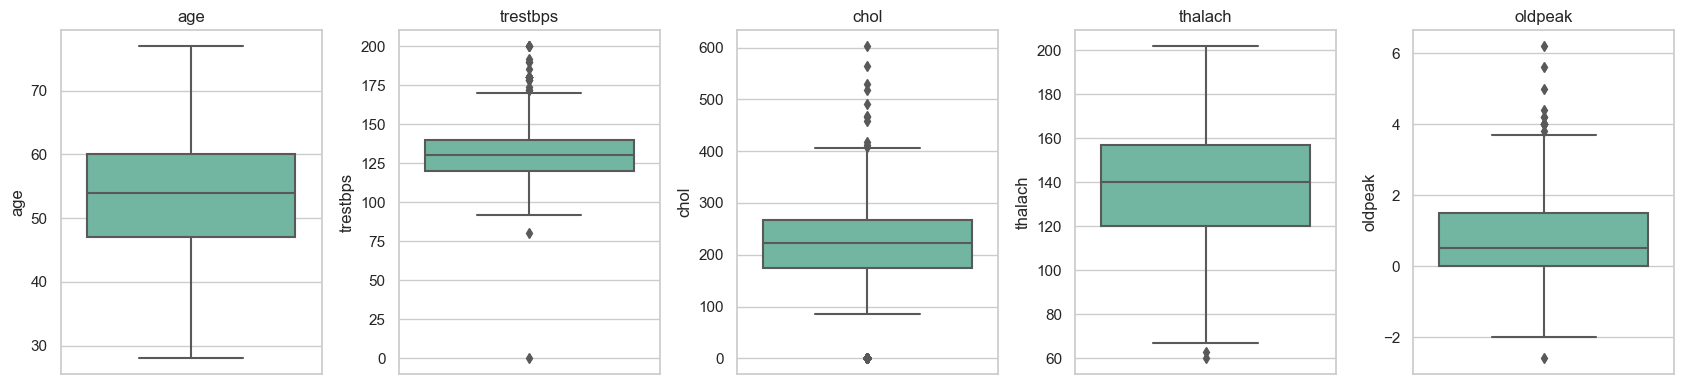

In [17]:
# 8-9. Anomalous values dan outlier analysis
print("8. ANOMALOUS VALUES (ATURAN DOMAIN)")
domain_rules = {
    "age": (0, 120),
    "sex": (0, 1),
    "cp": (1, 4),
    "trestbps": (50, 250),
    "chol": (50, 700),
    "fbs": (0, 1),
    "restecg": (0, 2),
    "thalach": (50, 250),
    "exang": (0, 1),
    "oldpeak": (-5, 10),
    "slope": (1, 3),
    "ca": (0, 3),
    "thal": (3, 7),
    "target": (0, 4),
}
anomaly_rows = []
for feature, (lower, upper) in domain_rules.items():
    mask = df[feature].notna() & ~df[feature].between(lower, upper)
    anomaly_rows.append({
        "feature": feature,
        "allowed_range": f"[{lower}, {upper}]",
        "anomaly_count": int(mask.sum()),
        "anomaly_percentage": mask.mean() * 100,
    })
anomaly_table = pd.DataFrame(anomaly_rows).sort_values("anomaly_count", ascending=False)
display(anomaly_table)
print("Catatan: batas domain adalah screening awal; nilai yang lolos tetap perlu ditinjau secara klinis.")

print("9. OUTLIER ANALYSIS (IQR)")
outlier_rows = []
for feature in numeric_features:
    values = df[feature].dropna()
    q1, q3 = values.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    mask = df[feature].notna() & ~df[feature].between(lower, upper)
    outlier_rows.append({
        "feature": feature,
        "q1": q1,
        "q3": q3,
        "lower_bound": lower,
        "upper_bound": upper,
        "outlier_count": int(mask.sum()),
        "outlier_percentage": mask.mean() * 100,
    })
outlier_table = pd.DataFrame(outlier_rows).sort_values("outlier_count", ascending=False)
display(outlier_table)

fig, axes = plt.subplots(1, len(numeric_features), figsize=(17, 4))
for axis, feature in zip(axes, numeric_features):
    sns.boxplot(data=df, y=feature, ax=axis)
    axis.set_title(feature)
plt.tight_layout()
plt.show()

10. HUBUNGAN FEATURE DENGAN TARGET
Rata-rata fitur numerik berdasarkan target biner:


target_binary         0       1
age      count  411.000 509.000
         mean    50.547  55.904
         median  51.000  57.000
trestbps count  391.000 470.000
         mean   129.913 133.979
         median 130.000 130.000
chol     count  392.000 498.000
         mean   227.906 176.480
         median 228.000 218.000
thalach  count  391.000 474.000
         mean   148.801 128.262
         median 151.000 128.000
oldpeak  count  390.000 468.000
         mean     0.418   1.263
         median   0.000   1.050

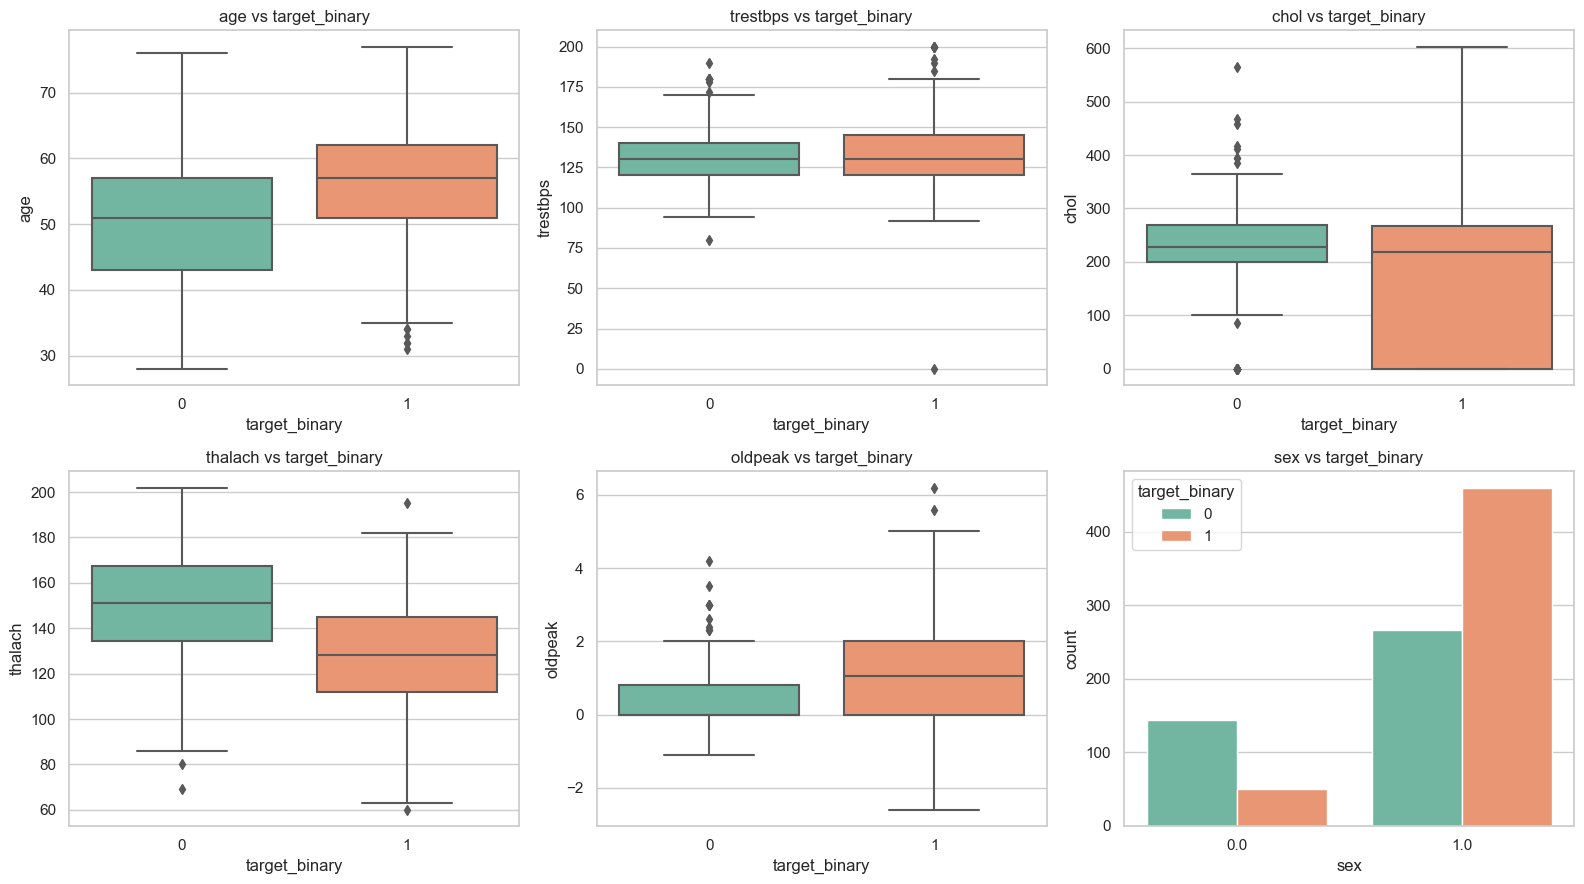


Positive rate berdasarkan sex


,count,positive_rate
sex,,
0.000,194,0.258
1.000,726,0.632



Positive rate berdasarkan cp


,count,positive_rate
cp,,
1.000,46,0.435
2.000,174,0.138
3.000,204,0.358
4.000,496,0.790



Positive rate berdasarkan fbs


...


Positive rate berdasarkan ca


,count,positive_rate
ca,,
0.000,181,0.265
1.000,67,0.687
2.000,41,0.805
3.000,20,0.850
NaN,611,0.597



Positive rate berdasarkan thal


,count,positive_rate
thal,,
3.000,196,0.296
6.000,46,0.761
7.000,192,0.802
NaN,486,0.539


11. CORRELATION ANALYSIS


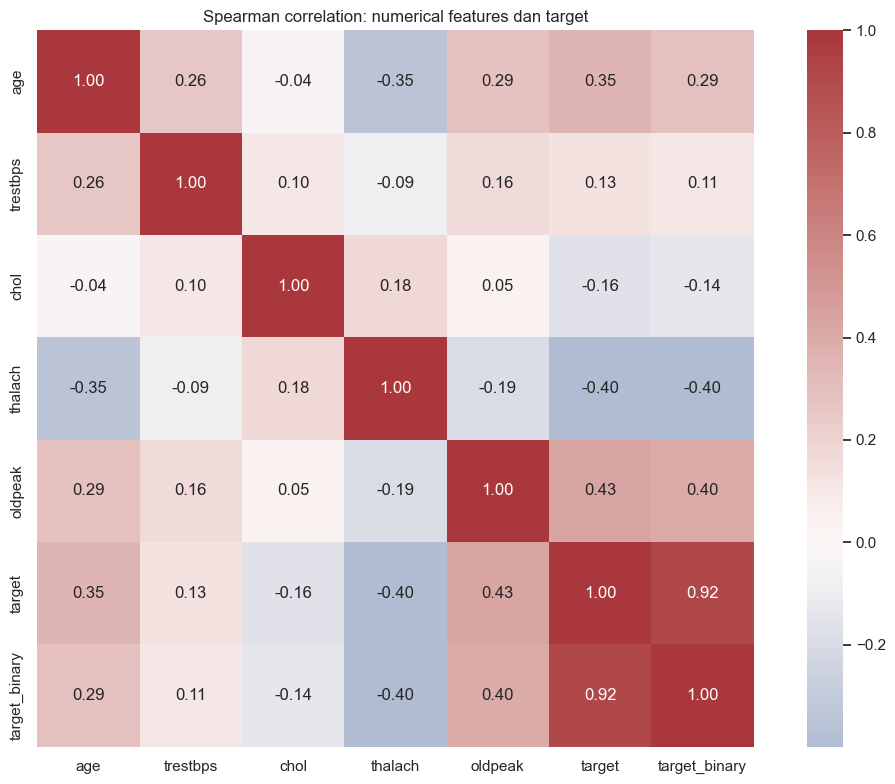

Korelasi fitur numerik terhadap target_binary:


,spearman_corr
target,0.916
oldpeak,0.401
thalach,-0.399
age,0.291
chol,-0.136
trestbps,0.108


In [18]:
# 10-11. Hubungan fitur dengan target dan correlation analysis
print("10. HUBUNGAN FEATURE DENGAN TARGET")
print("Rata-rata fitur numerik berdasarkan target biner:")
display(df.groupby("target_binary")[numeric_features].agg(["count", "mean", "median"]).T)

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for axis, feature in zip(axes.flat, numeric_features):
    sns.boxplot(data=df, x="target_binary", y=feature, ax=axis)
    axis.set_title(f"{feature} vs target_binary")
for axis, feature in zip(axes.flat[len(numeric_features):], categorical_features[:1]):
    sns.countplot(data=df, x=feature, hue="target_binary", ax=axis)
    axis.set_title(f"{feature} vs target_binary")
for axis in axes.flat[(len(numeric_features) + 1):]:
    axis.axis("off")
plt.tight_layout()
plt.show()

for feature in categorical_features:
    rates = df.groupby(feature, dropna=False)["target_binary"].agg(["count", "mean"])
    rates = rates.rename(columns={"mean": "positive_rate"})
    print(f"\nPositive rate berdasarkan {feature}")
    display(rates)

print("11. CORRELATION ANALYSIS")
correlation_columns = numeric_features + ["target", "target_binary"]
correlation_matrix = df[correlation_columns].corr(method="spearman")
plt.figure(figsize=(11, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="vlag", center=0, square=True)
plt.title("Spearman correlation: numerical features dan target")
plt.tight_layout()
plt.show()
print("Korelasi fitur numerik terhadap target_binary:")
display(correlation_matrix["target_binary"].drop("target_binary").sort_values(key=abs, ascending=False).to_frame("spearman_corr"))

In [19]:
# 12. Potential data leakage
print("12. POTENTIAL DATA LEAKAGE")

leakage_checks = pd.DataFrame({
    "column": ["target", "target_binary", "source_file"],
    "reason": [
        "Label asli; tidak boleh menjadi predictor.",
        "Label turunan dari target; tidak boleh menjadi predictor.",
        "Metadata sumber dataset; berpotensi membuat model belajar perbedaan subset/populasi.",
    ],
    "action": [
        "Drop sebelum split/train.",
        "Drop sebelum split/train; hanya dipakai sebagai y.",
        "Drop dari X atau evaluasi secara eksplisit sebagai analisis subgroup.",
    ],
})
display(leakage_checks)

# Fitur model yang aman hanya berasal dari pengukuran pasien.
model_features = [feature for feature in FEATURE_NAMES if feature != "target"]
X_eda = df[model_features].copy()
y_eda = df["target_binary"].copy()
print(f"Predictor awal yang dapat dipertimbangkan: {len(model_features)} fitur")
print("Wajib dilakukan setelah EDA: split train/test terlebih dahulu, lalu fit imputer/encoder hanya pada train.")

# Cari baris dengan fitur identik tetapi target berbeda, indikasi konflik label atau kebocoran pada proses pengumpulan.
feature_columns = [feature for feature in FEATURE_NAMES if feature != "target"]
conflicting_groups = (
    df.dropna(subset=feature_columns)
      .groupby(feature_columns, dropna=False)["target"]
      .nunique()
)
print(f"Grup fitur identik dengan target berbeda: {(conflicting_groups > 1).sum():,}")
print("Interpretasi: target tidak dipakai sebagai fitur; source_file diperlakukan sebagai metadata, dan preprocessing di-fit setelah pembagian data.")

12. POTENTIAL DATA LEAKAGE


,column,reason,action
0,target,Label asli; tidak boleh menjadi predictor.,Drop sebelum split/train.
1,target_binary,Label turunan dari target; tidak boleh menjadi...,Drop sebelum split/train; hanya dipakai sebaga...
2,source_file,Metadata sumber dataset; berpotensi membuat mo...,Drop dari X atau evaluasi secara eksplisit seb...


Predictor awal yang dapat dipertimbangkan: 13 fitur
Wajib dilakukan setelah EDA: split train/test terlebih dahulu, lalu fit imputer/encoder hanya pada train.
Grup fitur identik dengan target berbeda: 0
Interpretasi: target tidak dipakai sebagai fitur; source_file diperlakukan sebagai metadata, dan preprocessing di-fit setelah pembagian data.


# Corrected Preprocessing Pipeline

## Keputusan preprocessing

- `X` dan `y` dipisahkan sebelum pembagian data. `target_binary` menjadi `y`; `target` dan `source_file` dikeluarkan dari predictor untuk mencegah leakage.
- Data dibagi menggunakan stratified train-test split. Stratifikasi menjaga proporsi kelas pada train dan test.
- Semua transformer di dalam pipeline hanya di-fit pada training set. Dengan demikian median imputasi, kategori hasil encoding, dan parameter scaling tidak melihat test set.
- Missing values numerik diisi dengan median training, sedangkan missing values kategorikal diisi dengan modus training.
- Logistic Regression sensitif terhadap skala fitur numerik, sehingga `StandardScaler` digunakan pada fitur numerik. One-hot encoded features tidak diskalakan lagi.
- Tidak digunakan SMOTE, feature selection tambahan, maupun hyperparameter tuning. Model dan parameternya ditetapkan satu kali.
- Test set hanya digunakan untuk evaluasi final setelah pipeline selesai di-fit pada training set.

In [20]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# 1. Pisahkan predictor dan target sebelum split.
# target_binary adalah label; target asli dan source_file tidak boleh masuk ke X.
X = df.drop(columns=["target", "target_binary", "source_file"]).copy()
y = df["target_binary"].astype(int).copy()

print(f"X shape sebelum split: {X.shape}")
print(f"y shape sebelum split: {y.shape}")
print("Distribusi y:")
display(y.value_counts(normalize=True).rename("proportion").to_frame())

# 2. Split dilakukan sebelum transformer dibuat dan di-fit.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y,
)

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"Proporsi kelas train: {y_train.mean():.3f}")
print(f"Proporsi kelas test: {y_test.mean():.3f}")

# Kolom kategorikal diperlakukan sebagai kategori walaupun tersimpan sebagai angka.
numeric_features_model = ["age", "trestbps", "chol", "thalach", "oldpeak"]
categorical_features_model = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"]

numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_pipeline, numeric_features_model),
        ("categorical", categorical_pipeline, categorical_features_model),
    ],
    remainder="drop",
)

# 3. Pipeline mem-fit preprocessing dan model hanya menggunakan training set.
# Tidak ada SMOTE, feature selection, atau tuning tambahan.
model_pipeline = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("model", LogisticRegression(max_iter=1000, random_state=42)),
])

model_pipeline.fit(X_train, y_train)
print("Pipeline berhasil di-fit pada training set.")

# Verifikasi bahwa parameter imputer berasal dari training set dan test belum di-fit.
trained_preprocessor = model_pipeline.named_steps["preprocessing"]
trained_numeric_imputer = trained_preprocessor.named_transformers_["numeric"].named_steps["imputer"]
print("Median imputasi training:")
display(pd.Series(trained_numeric_imputer.statistics_, index=numeric_features_model, name="training_median"))

X shape sebelum split: (920, 13)
y shape sebelum split: (920,)
Distribusi y:


,proportion
1,0.553
0,0.447


X_train: (736, 13), X_test: (184, 13)
Proporsi kelas train: 0.553
Proporsi kelas test: 0.554
Pipeline berhasil di-fit pada training set.
Median imputasi training:


age         54.000
trestbps   130.000
chol       223.000
thalach    140.000
oldpeak      0.500
Name: training_median, dtype: float64

## Final evaluation

Prediksi pada `X_test` dilakukan hanya setelah seluruh preprocessing dan model selesai di-fit dengan `X_train`. Tidak ada informasi dari test set yang digunakan untuk memilih atau mengubah parameter pipeline.

In [21]:
# 4. Test set hanya dipakai untuk final evaluation.
y_test_pred = model_pipeline.predict(X_test)
y_test_proba = model_pipeline.predict_proba(X_test)[:, 1]

print("FINAL TEST EVALUATION")
print(f"Accuracy : {accuracy_score(y_test, y_test_pred):.3f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_test_proba):.3f}")
print("\nClassification report:")
print(classification_report(y_test, y_test_pred, target_names=["No disease", "Disease"]))

confusion = pd.DataFrame(
    confusion_matrix(y_test, y_test_pred),
    index=["Actual 0", "Actual 1"],
    columns=["Predicted 0", "Predicted 1"],
)
display(confusion)

print("Jumlah fitur setelah preprocessing:", len(model_pipeline.named_steps["preprocessing"].get_feature_names_out()))

FINAL TEST EVALUATION
Accuracy : 0.842
ROC-AUC  : 0.908

Classification report:
              precision    recall  f1-score   support

  No disease       0.84      0.80      0.82        82
     Disease       0.85      0.87      0.86       102

    accuracy                           0.84       184
   macro avg       0.84      0.84      0.84       184
weighted avg       0.84      0.84      0.84       184



,Predicted 0,Predicted 1
Actual 0,66,16
Actual 1,13,89


Jumlah fitur setelah preprocessing: 28
